# 05 -- Random Forest


Мы решаем регрессию задержки `target_delay_s`; основная метрика -- MAE в секундах.

Здесь я использую более строгий протокол, чем обычный random split:

* в train реальные ТС и synthetic ТС разделены по `tr_id`; synthetic имеют ID `9000000+`;
* test и validate состоят из реальных ТС, причем их `tr_id` уже встречаются в train;
* основной CV поэтому строю внутри реальных ТС блоками по времени;
* вокруг validation блока удаляю train точки того же ТС в радиусе 45 минут -- это покрывает максимальные 30 минут истории признаков и 15 минут prediction horizon;
* synthetic никогда не попадает в validation -- его вес в train подбираю как гиперпараметр;
* `test` не использую ни в Optuna, ни в выборе direct/residual -- открываю его один раз после фиксации модели;
* после этой проверки test можно легально добавить к train и отдельно донастроить финальную модель для hidden validate.

Глобальные `pca_core_*` из `02_feature_engineering.ipynb` в CV не использую: PCA там fit'ился на всем train. Для честной оценки любое обучаемое преобразование должно fit'иться только внутри fold.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

from tqdm import TqdmWarning

with warnings.catch_warnings():
    warnings.simplefilter('ignore', TqdmWarning)
    import optuna

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OrdinalEncoder

RF_SEED = 143
RF_TUNE_FOLDS = 4
RF_OOF_FOLDS = 5
RF_STRESS_FOLDS = 5
RF_PURGE_MINUTES = 45
RF_TRIALS_PER_MODE = 50
RF_FINAL_TRIALS = 20
RF_TUNE_ESTIMATORS = 450
RF_EVAL_ESTIMATORS = 900
RF_FINAL_ESTIMATORS = 1500
RF_MODES = ['direct', 'residual']
RF_SYNTHETIC_WEIGHTS = [0.0, .1, .25, .5, .75, 1.0]
RF_CLIP_Q = [0.0, .001, .005, .01]

## 1. Данные и audit

Глобальные PCA признаки исключаю. Для RF категориальные поля кодирую ordinal encoder'ом, который fit'ится отдельно в каждом fold. Это не приписывает категориям физический порядок -- деревья просто получают стабильные числовые коды; CatBoost дальше обработает категории нативно.

In [2]:
rf_features_dir = Path('../dataset/features')

rf_train = pd.read_pickle(rf_features_dir / 'train_features.pkl').reset_index(drop=True)
rf_test = pd.read_pickle(rf_features_dir / 'test_features.pkl').reset_index(drop=True)
rf_validate = pd.read_pickle(rf_features_dir / 'validate_features.pkl').reset_index(drop=True)

rf_saved_features = pd.read_csv(rf_features_dir / 'feature_columns.csv').feature.tolist()
rf_saved_categorical = pd.read_csv(rf_features_dir / 'categorical_features.csv').feature.tolist()

rf_feature_cols = [
    rf_col for rf_col in rf_saved_features
    if not rf_col.startswith('pca_core_')
]
rf_categorical_features = [
    rf_col for rf_col in rf_saved_categorical
    if rf_col in rf_feature_cols
]
rf_numeric_features = [
    rf_col for rf_col in rf_feature_cols
    if rf_col not in rf_categorical_features
    and pd.api.types.is_numeric_dtype(rf_train[rf_col].dtype)
]

assert not {'target_delay_s', 'target_class'} & set(rf_feature_cols)
assert not any(rf_col.startswith('pca_core_') for rf_col in rf_feature_cols)
assert set(rf_train.sample_id).isdisjoint(set(rf_test.sample_id))
assert set(rf_train.sample_id).isdisjoint(set(rf_validate.sample_id))

pd.Series({
    'train_rows': len(rf_train),
    'train_real_rows': (rf_train.tr_id < 9_000_000).sum(),
    'train_synthetic_rows': (rf_train.tr_id >= 9_000_000).sum(),
    'test_rows': len(rf_test),
    'validate_rows': len(rf_validate),
    'numeric_features': len(rf_numeric_features),
    'categorical_features': len(rf_categorical_features),
})

train_rows              4434
train_real_rows         1141
train_synthetic_rows    3293
test_rows                353
validate_rows            151
numeric_features         680
categorical_features      12
dtype: int64

## 2. Leakage safe CV

Основной splitter имитирует структуру hidden validate лучше, чем `GroupKFold`: у каждого реального ТС я делю точки на последовательные временные блоки. Validation fold содержит один блок от каждого реального ТС. Из train дополнительно вычищаю точки того же ТС на 45 минут до и после validation блока.

Synthetic остается только в train. Так Optuna оценивает гиперпараметры на реальных точках, но может решить, помогает ли дополнительная синтетика.

Дополнительно после tuning запускаю `GroupKFold` по реальным `tr_id` как stress-test -- он отвечает на более строгий вопрос о переносе на полностью невиданное ТС, хотя hidden validate устроен не так.

In [3]:
def rf_build_purged_folds(data, n_splits, purge_minutes):
    rf_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    rf_frame['T'] = pd.to_datetime(rf_frame['T'])
    rf_frame['is_synthetic'] = rf_frame.tr_id >= 9_000_000
    rf_frame['cv_fold'] = -1

    for rf_tr_id, rf_idx in rf_frame.loc[~rf_frame.is_synthetic].groupby('tr_id').groups.items():
        rf_ordered = rf_frame.loc[rf_idx].sort_values('T').index.to_numpy()
        for rf_fold, rf_chunk in enumerate(np.array_split(rf_ordered, n_splits)):
            rf_frame.loc[rf_chunk, 'cv_fold'] = rf_fold

    rf_folds = []
    rf_purge = pd.Timedelta(minutes=purge_minutes)

    for rf_fold in range(n_splits):
        rf_valid_mask = (~rf_frame.is_synthetic) & (rf_frame.cv_fold == rf_fold)
        rf_train_mask = ~rf_valid_mask

        for rf_tr_id, rf_valid_part in rf_frame.loc[rf_valid_mask].groupby('tr_id'):
            rf_left = rf_valid_part['T'].min() - rf_purge
            rf_right = rf_valid_part['T'].max() + rf_purge
            rf_near_valid = (
                (~rf_frame.is_synthetic)
                & (rf_frame.tr_id == rf_tr_id)
                & rf_frame['T'].between(rf_left, rf_right)
            )
            rf_train_mask &= ~rf_near_valid

        rf_folds.append((
            np.flatnonzero(rf_train_mask.to_numpy()),
            np.flatnonzero(rf_valid_mask.to_numpy())
        ))

    return rf_folds


def rf_build_group_stress_folds(data, n_splits):
    rf_real_idx = np.flatnonzero((data.tr_id < 9_000_000).to_numpy())
    rf_synthetic_idx = np.flatnonzero((data.tr_id >= 9_000_000).to_numpy())
    rf_splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=RF_SEED)
    rf_folds = []

    for rf_real_train_local, rf_real_valid_local in rf_splitter.split(
        rf_real_idx,
        groups=data.iloc[rf_real_idx].tr_id
    ):
        rf_train_idx = np.concatenate([
            rf_real_idx[rf_real_train_local],
            rf_synthetic_idx
        ])
        rf_valid_idx = rf_real_idx[rf_real_valid_local]
        rf_folds.append((rf_train_idx, rf_valid_idx))

    return rf_folds


def rf_check_purged_folds(data, folds, purge_minutes):
    rf_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    rf_frame['T'] = pd.to_datetime(rf_frame['T'])
    rf_purge = pd.Timedelta(minutes=purge_minutes)
    rf_rows = []

    for rf_fold, (rf_train_idx, rf_valid_idx) in enumerate(folds):
        rf_train = rf_frame.iloc[rf_train_idx]
        rf_valid = rf_frame.iloc[rf_valid_idx]
        rf_min_gap = np.inf

        for rf_tr_id, rf_valid_part in rf_valid.groupby('tr_id'):
            rf_train_times = rf_train.loc[rf_train.tr_id == rf_tr_id, 'T']
            if len(rf_train_times) == 0:
                continue
            rf_gap = np.abs(
                rf_train_times.to_numpy()[:, None]
                - rf_valid_part['T'].to_numpy()[None, :]
            ).min()
            rf_min_gap = min(rf_min_gap, rf_gap / np.timedelta64(1, 'm'))

        rf_rows.append({
            'fold': rf_fold,
            'train_rows': len(rf_train_idx),
            'valid_rows': len(rf_valid_idx),
            'valid_tr_ids': rf_valid.tr_id.nunique(),
            'min_same_tr_gap_min': rf_min_gap
        })

    rf_result = pd.DataFrame(rf_rows)
    assert (rf_result.min_same_tr_gap_min >= purge_minutes).all()
    return rf_result

In [4]:
rf_tune_folds = rf_build_purged_folds(rf_train, RF_TUNE_FOLDS, RF_PURGE_MINUTES)
rf_oof_folds = rf_build_purged_folds(rf_train, RF_OOF_FOLDS, RF_PURGE_MINUTES)
rf_stress_folds = rf_build_group_stress_folds(rf_train, RF_STRESS_FOLDS)
rf_fold_audit = rf_check_purged_folds(rf_train, rf_oof_folds, RF_PURGE_MINUTES)
rf_fold_audit

,fold,train_rows,valid_rows,valid_tr_ids,min_same_tr_gap_min
0,0,4130,233,13,50.0
1,1,4042,231,13,50.0
2,2,4082,228,13,50.0
3,3,4060,226,13,50.0
4,4,4149,223,13,50.0


## 3. Fold safe preprocessing

In [5]:
def rf_prepare_frame(data):
    rf_frame = data[rf_numeric_features + rf_categorical_features].copy()
    for rf_col in rf_categorical_features:
        rf_frame[rf_col] = (
            rf_frame[rf_col]
            .astype('string')
            .fillna('__missing__')
            .astype(str)
        )
    return rf_frame


def rf_make_preprocessor():
    return ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median', add_indicator=True), rf_numeric_features),
        ('categorical', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), rf_categorical_features)
    ])


def rf_sample_weight(data, synthetic_weight):
    return np.where(
        data.tr_id.to_numpy() >= 9_000_000,
        synthetic_weight,
        1.0
    )


def rf_clip_prediction(prediction, y_train, q):
    if q == 0:
        return prediction
    rf_low, rf_high = y_train.quantile([q, 1 - q])
    return np.clip(prediction, rf_low, rf_high)

In [6]:
rf_x_train = rf_prepare_frame(rf_train)
rf_x_test = rf_prepare_frame(rf_test)
rf_x_validate = rf_prepare_frame(rf_validate)
rf_y_train = rf_train.target_delay_s.astype(float)
rf_y_test = rf_test.target_delay_s.astype(float)
rf_cur_train = rf_train.cur_dev_s.astype(float)
rf_cur_test = rf_test.cur_dev_s.astype(float)
rf_cur_validate = rf_validate.cur_dev_s.astype(float)

## 4. Optuna -- hyperparameter search

Во время search число деревьев фиксирую на 450: этого достаточно, чтобы сравнивать структуру леса, и это не тратит бюджет на почти монотонный параметр. После tuning OOF считаю уже на 900 деревьях, а финальную модель -- на 1500.

Подбираю глубину, размер листа, долю признаков, bootstrap, долю строк в дереве, criterion, минимальное уменьшение impurity, вес synthetic и postprocessing.

In [7]:
def rf_suggest_params(trial):
    rf_unlimited = trial.suggest_categorical('unlimited_depth', [False, True])
    rf_bootstrap = trial.suggest_categorical('bootstrap', [False, True])
    rf_params = {
        'max_depth': None if rf_unlimited else trial.suggest_int('max_depth', 6, 32),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 24),
        'max_features': trial.suggest_float('max_features', .2, 1.0),
        'bootstrap': rf_bootstrap,
        'criterion': 'squared_error',
        'min_impurity_decrease': trial.suggest_float(
            'min_impurity_decrease', 1e-9, 1e-3, log=True
        ),
        'synthetic_weight': trial.suggest_categorical(
            'synthetic_weight', RF_SYNTHETIC_WEIGHTS
        ),
        'clip_q': trial.suggest_categorical('clip_q', RF_CLIP_Q),
    }
    rf_params['max_samples'] = (
        trial.suggest_float('max_samples', .55, 1.0)
        if rf_bootstrap else None
    )
    return rf_params


def rf_make_model(params, n_estimators):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        min_samples_split=params['min_samples_split'],
        max_features=params['max_features'],
        bootstrap=params['bootstrap'],
        max_samples=params['max_samples'],
        criterion=params['criterion'],
        min_impurity_decrease=params['min_impurity_decrease'],
        n_jobs=-1,
        random_state=RF_SEED
    )


def rf_objective(trial, mode, data, x, y, cur_dev, folds):
    rf_params = rf_suggest_params(trial)
    rf_scores = []

    for rf_fold, (rf_train_idx, rf_valid_idx) in enumerate(folds):
        rf_train_part = data.iloc[rf_train_idx]
        rf_weights = rf_sample_weight(rf_train_part, rf_params['synthetic_weight'])
        rf_active = rf_weights > 0

        rf_preprocessor = rf_make_preprocessor()
        rf_train_matrix = rf_preprocessor.fit_transform(
            x.iloc[rf_train_idx].loc[rf_active]
        )
        rf_valid_matrix = rf_preprocessor.transform(x.iloc[rf_valid_idx])

        rf_fit_target = y.iloc[rf_train_idx].loc[rf_active].copy()
        if mode == 'residual':
            rf_fit_target = rf_fit_target - cur_dev.iloc[rf_train_idx].loc[rf_active]

        rf_model = rf_make_model(rf_params, RF_TUNE_ESTIMATORS)
        rf_model.fit(
            rf_train_matrix,
            rf_fit_target,
            sample_weight=rf_weights[rf_active]
        )

        rf_prediction = rf_model.predict(rf_valid_matrix)
        if mode == 'residual':
            rf_prediction += cur_dev.iloc[rf_valid_idx].to_numpy()
        rf_prediction = rf_clip_prediction(
            rf_prediction,
            y.iloc[rf_train_idx].loc[rf_active],
            rf_params['clip_q']
        )
        rf_scores.append(mean_absolute_error(y.iloc[rf_valid_idx], rf_prediction))

        trial.report(np.mean(rf_scores), step=rf_fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rf_scores))

In [8]:
rf_artifact_dir = Path('../artifacts/models/random_forest')
rf_artifact_dir.mkdir(parents=True, exist_ok=True)
rf_storage = f"sqlite:///{(rf_artifact_dir / 'optuna.db').resolve()}"
rf_studies = {}

for rf_mode in RF_MODES:
    rf_study = optuna.create_study(
        study_name=f'rf_{rf_mode}_train',
        storage=rf_storage,
        load_if_exists=True,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RF_SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1)
    )
    rf_finished = sum(
        rf_trial.state in {
            optuna.trial.TrialState.COMPLETE,
            optuna.trial.TrialState.PRUNED
        }
        for rf_trial in rf_study.trials
    )
    rf_remaining = max(0, RF_TRIALS_PER_MODE - rf_finished)
    if rf_remaining:
        rf_study.optimize(
            lambda rf_trial, rf_mode=rf_mode: rf_objective(
                rf_trial,
                rf_mode,
                rf_train,
                rf_x_train,
                rf_y_train,
                rf_cur_train,
                rf_tune_folds
            ),
            n_trials=rf_remaining,
            n_jobs=1,
            show_progress_bar=False
        )
    rf_studies[rf_mode] = rf_study

[I 2026-09-27 01:46:00,289] Using an existing study with `study_name='rf_direct_train'` instead of creating a new one.
[I 2026-09-27 01:46:00,331] Using an existing study with `study_name='rf_residual_train'` instead of creating a new one.


In [9]:
def rf_study_summary(studies):
    rf_rows = []
    for rf_mode, rf_study in studies.items():
        rf_complete = [
            rf_trial for rf_trial in rf_study.trials
            if rf_trial.state == optuna.trial.TrialState.COMPLETE
        ]
        rf_rows.append({
            'mode': rf_mode,
            'trials': len(rf_study.trials),
            'complete': len(rf_complete),
            'best_cv_mae': rf_study.best_value
        })
    return pd.DataFrame(rf_rows).sort_values('best_cv_mae')


def rf_plot_study(study, title):
    rf_completed = pd.DataFrame([
        {
            'number': rf_trial.number,
            'value': rf_trial.value
        }
        for rf_trial in study.trials
        if rf_trial.state == optuna.trial.TrialState.COMPLETE
    ]).sort_values('number')
    rf_completed['best_so_far'] = rf_completed.value.cummin()

    rf_fig, rf_axes = plt.subplots(1, 2, figsize=(14, 4))
    rf_axes[0].scatter(rf_completed.number, rf_completed.value, s=24, alpha=.65)
    rf_axes[0].plot(rf_completed.number, rf_completed.best_so_far, linewidth=2)
    rf_axes[0].set_title(f'{title} -- optimization history')
    rf_axes[0].set_xlabel('trial')
    rf_axes[0].set_ylabel('CV MAE, sec')

    rf_importance = optuna.importance.get_param_importances(study)
    pd.Series(rf_importance).sort_values().plot.barh(ax=rf_axes[1])
    rf_axes[1].set_title(f'{title} -- Optuna param importance')
    rf_axes[1].set_xlabel('importance')
    plt.tight_layout()

In [10]:
rf_study_table = rf_study_summary(rf_studies)
rf_study_table

,mode,trials,complete,best_cv_mae
0,direct,50,44,40.712716
1,residual,50,43,43.708474


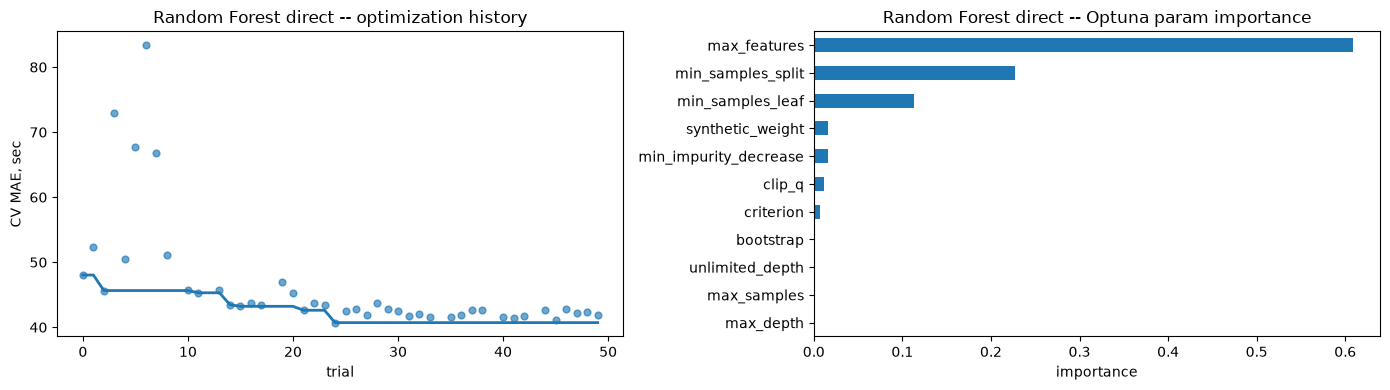

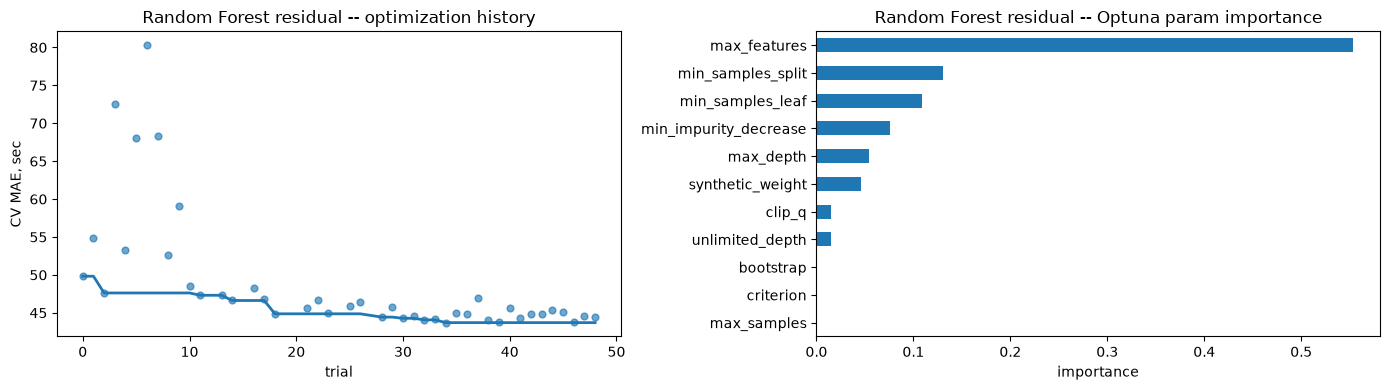

In [11]:
for rf_mode, rf_study in rf_studies.items():
    rf_plot_study(rf_study, f'Random Forest {rf_mode}')

In [12]:
rf_best_mode = rf_study_table.iloc[0]['mode']
rf_best_study = rf_studies[rf_best_mode]
rf_best_params = rf_suggest_params(rf_best_study.best_trial)
pd.Series(rf_best_params, name='value').to_frame()

,value
max_depth,None
min_samples_leaf,1
min_samples_split,3
max_features,0.222034
bootstrap,False
criterion,squared_error
min_impurity_decrease,0.0
synthetic_weight,0.75
clip_q,0.005
max_samples,None


## 5. OOF и стабильность feature importance

In [13]:
def rf_fit_fold(data, x, y, cur_dev, train_idx, valid_idx, mode, params, n_estimators):
    rf_train_part = data.iloc[train_idx]
    rf_weights = rf_sample_weight(rf_train_part, params['synthetic_weight'])
    rf_active = rf_weights > 0

    rf_preprocessor = rf_make_preprocessor()
    rf_train_matrix = rf_preprocessor.fit_transform(x.iloc[train_idx].loc[rf_active])
    rf_valid_matrix = rf_preprocessor.transform(x.iloc[valid_idx])

    rf_fit_target = y.iloc[train_idx].loc[rf_active].copy()
    if mode == 'residual':
        rf_fit_target = rf_fit_target - cur_dev.iloc[train_idx].loc[rf_active]

    rf_model = rf_make_model(params, n_estimators)
    rf_model.fit(
        rf_train_matrix,
        rf_fit_target,
        sample_weight=rf_weights[rf_active]
    )
    rf_prediction = rf_model.predict(rf_valid_matrix)
    if mode == 'residual':
        rf_prediction += cur_dev.iloc[valid_idx].to_numpy()
    rf_prediction = rf_clip_prediction(
        rf_prediction,
        y.iloc[train_idx].loc[rf_active],
        params['clip_q']
    )
    return rf_model, rf_preprocessor, rf_prediction


def rf_oof_predict(data, x, y, cur_dev, folds, mode, params, n_estimators):
    rf_parts = []
    rf_importances = []

    for rf_fold, (rf_train_idx, rf_valid_idx) in enumerate(folds):
        rf_model, rf_preprocessor, rf_prediction = rf_fit_fold(
            data, x, y, cur_dev,
            rf_train_idx, rf_valid_idx,
            mode, params, n_estimators
        )
        rf_part = data.iloc[rf_valid_idx][['sample_id', 'tr_id', 'T']].copy()
        rf_part['fold'] = rf_fold
        rf_part['target'] = y.iloc[rf_valid_idx].to_numpy()
        rf_part['prediction'] = rf_prediction
        rf_part['error'] = rf_part.target - rf_part.prediction
        rf_part['abs_error'] = rf_part.error.abs()
        rf_parts.append(rf_part)

        rf_feature_names = rf_preprocessor.get_feature_names_out()
        rf_importances.append(pd.Series(
            rf_model.feature_importances_,
            index=rf_feature_names,
            name=rf_fold
        ))

    return pd.concat(rf_parts, ignore_index=True), pd.concat(rf_importances, axis=1)

In [14]:
rf_oof, rf_fold_importance = rf_oof_predict(
    rf_train,
    rf_x_train,
    rf_y_train,
    rf_cur_train,
    rf_oof_folds,
    rf_best_mode,
    rf_best_params,
    RF_EVAL_ESTIMATORS
)

pd.Series({
    'oof_mae': rf_oof.abs_error.mean(),
    'oof_median_abs_error': rf_oof.abs_error.median(),
    'oof_p90_abs_error': rf_oof.abs_error.quantile(.9),
})

oof_mae                 41.345142
oof_median_abs_error    30.430079
oof_p90_abs_error       93.039603
dtype: float64

In [15]:
def rf_plot_oof(oof):
    rf_fig, rf_axes = plt.subplots(2, 2, figsize=(14, 10))

    rf_axes[0, 0].scatter(oof.target, oof.prediction, s=18, alpha=.4)
    rf_axes[0, 0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
    rf_axes[0, 0].set_title('OOF -- prediction vs target')
    rf_axes[0, 0].set_xlabel('target, sec')
    rf_axes[0, 0].set_ylabel('prediction, sec')

    rf_axes[0, 1].hist(oof.error, bins=60)
    rf_axes[0, 1].axvline(0, linewidth=1)
    rf_axes[0, 1].set_title('OOF -- error distribution')
    rf_axes[0, 1].set_xlabel('target - prediction, sec')

    rf_fold_mae = oof.groupby('fold').abs_error.mean()
    rf_fold_mae.plot.bar(ax=rf_axes[1, 0])
    rf_axes[1, 0].set_title('MAE по fold')
    rf_axes[1, 0].set_ylabel('MAE, sec')
    rf_axes[1, 0].tick_params(axis='x', rotation=0)

    rf_tr_mae = oof.groupby('tr_id').abs_error.mean().sort_values()
    rf_tr_mae.plot.barh(ax=rf_axes[1, 1])
    rf_axes[1, 1].set_title('MAE по real tr_id')
    rf_axes[1, 1].set_xlabel('MAE, sec')

    plt.tight_layout()

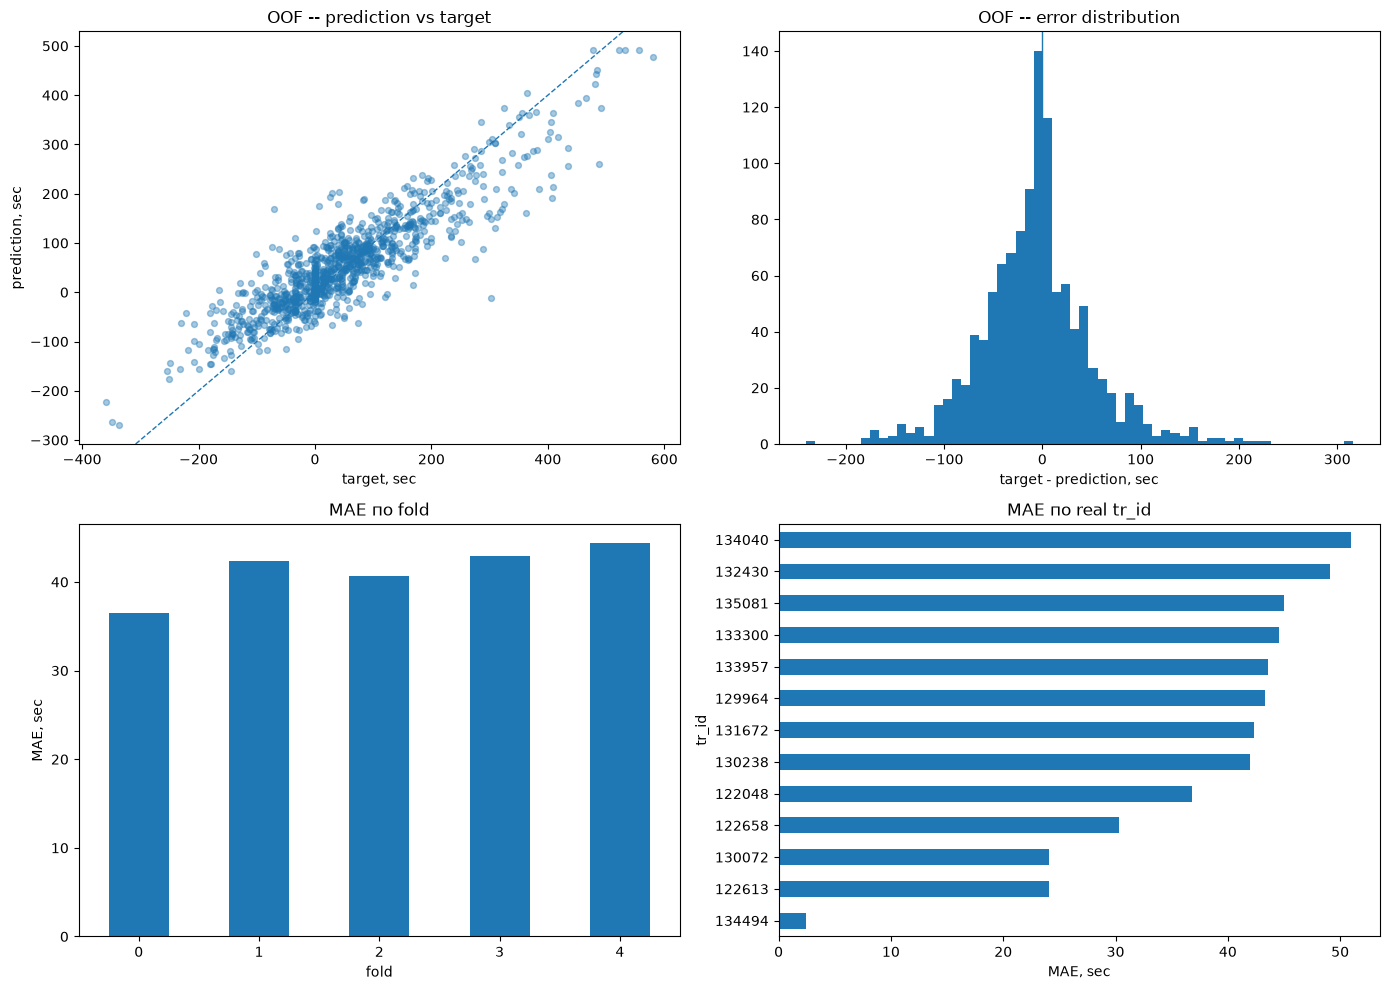

In [16]:
rf_plot_oof(rf_oof)

In [17]:
rf_importance_stability = pd.DataFrame({
    'mean_importance': rf_fold_importance.mean(axis=1),
    'std_importance': rf_fold_importance.std(axis=1),
})
rf_importance_stability['stability_ratio'] = (
    rf_importance_stability.mean_importance
    / (rf_importance_stability.std_importance + 1e-12)
)
rf_importance_stability.sort_values('mean_importance', ascending=False).head(30)

,mean_importance,std_importance,stability_ratio
numeric__cur_dev_per_min,0.057248,0.010566,5.418191
numeric__cur_dev_sqrt,0.038526,0.003538,10.888672
numeric__cur_dev_s,0.037259,0.003026,12.312882
numeric__cur_dev_log,0.036957,0.002269,16.290036
numeric__cur_dev_x_w15_valid_share,0.027877,0.003739,7.454810
numeric__cur_dev_x_horizon,0.024690,0.002660,9.283081
numeric__planned_seconds_per_stop,0.020268,0.000853,23.754473
numeric__scheduled_stops_per_min,0.019993,0.001117,17.901676
numeric__cur_dev_x_hour_sin,0.014668,0.001288,11.389903
numeric__cur_dev_x_required_speed_signed_log1p,0.013105,0.002224,5.892484


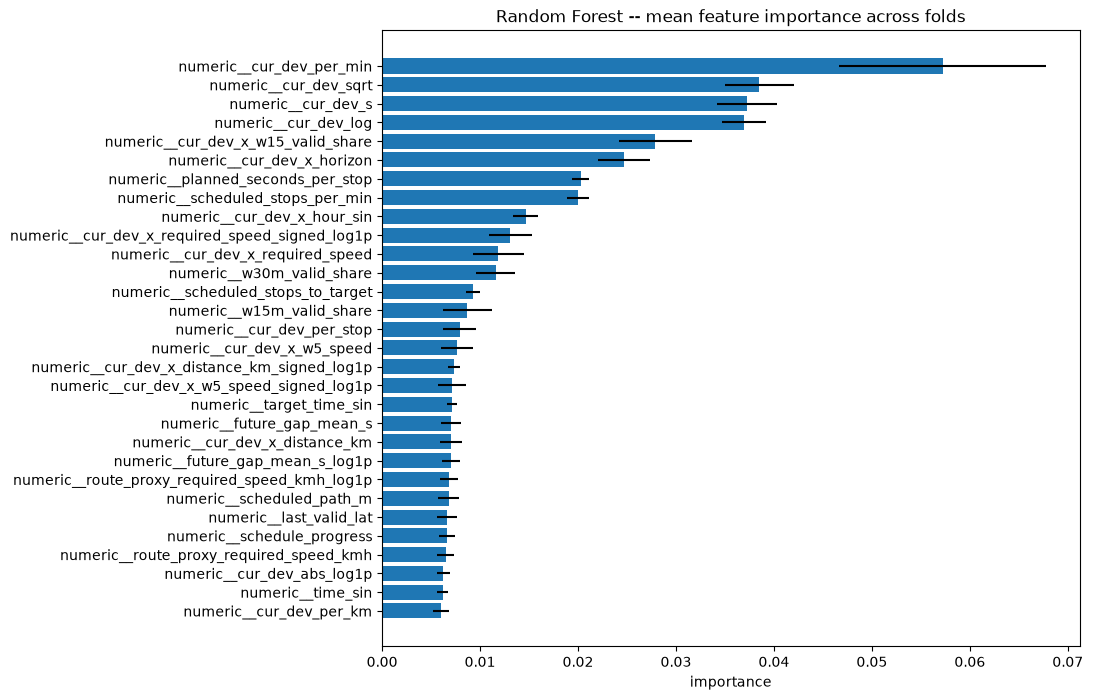

In [18]:
rf_top_importance = rf_importance_stability.nlargest(30, 'mean_importance').sort_values('mean_importance')
plt.figure(figsize=(9, 8))
plt.barh(
    rf_top_importance.index,
    rf_top_importance.mean_importance,
    xerr=rf_top_importance.std_importance
)
plt.title('Random Forest -- mean feature importance across folds')
plt.xlabel('importance')
plt.show()

## 6. GroupKFold stress-test

In [19]:
rf_stress_oof, rf_stress_importance = rf_oof_predict(
    rf_train,
    rf_x_train,
    rf_y_train,
    rf_cur_train,
    rf_stress_folds,
    rf_best_mode,
    rf_best_params,
    RF_EVAL_ESTIMATORS
)

pd.Series({
    'purged_oof_mae': rf_oof.abs_error.mean(),
    'unseen_tr_id_mae': rf_stress_oof.abs_error.mean()
})

purged_oof_mae      41.345142
unseen_tr_id_mae    41.566829
dtype: float64

## 7. Learning curve

In [20]:
def rf_fraction_mask(data, train_idx, fraction, seed):
    rf_part = data.iloc[train_idx]
    rf_real_idx = rf_part.index[rf_part.tr_id < 9_000_000].to_numpy()
    rf_synthetic_idx = rf_part.index[rf_part.tr_id >= 9_000_000].to_numpy()
    rf_rng = np.random.default_rng(seed)
    rf_score = pd.Series(rf_rng.random(len(rf_real_idx)), index=rf_real_idx)
    rf_selected_real = rf_score.index[rf_score <= fraction].to_numpy()
    return np.concatenate([rf_selected_real, rf_synthetic_idx])

In [21]:
def rf_learning_curve(data, x, y, cur_dev, fold, mode, params, fractions):
    rf_train_idx, rf_valid_idx = fold
    rf_rows = []

    for rf_fraction in fractions:
        rf_fraction_idx = rf_fraction_mask(data, rf_train_idx, rf_fraction, RF_SEED)
        _, _, rf_prediction = rf_fit_fold(
            data, x, y, cur_dev,
            rf_fraction_idx, rf_valid_idx,
            mode, params, RF_EVAL_ESTIMATORS
        )
        rf_rows.append({
            'real_fraction': rf_fraction,
            'train_rows': len(rf_fraction_idx),
            'valid_mae': mean_absolute_error(y.iloc[rf_valid_idx], rf_prediction)
        })

    return pd.DataFrame(rf_rows)

In [22]:
rf_learning = rf_learning_curve(
    rf_train,
    rf_x_train,
    rf_y_train,
    rf_cur_train,
    rf_oof_folds[0],
    rf_best_mode,
    rf_best_params,
    [.2, .4, .6, .8, 1.0]
)
rf_learning

,real_fraction,train_rows,valid_mae
0,0.2,3458,35.629618
1,0.4,3620,35.983511
2,0.6,3793,35.972506
3,0.8,3957,35.945030
4,1.0,4130,36.550591


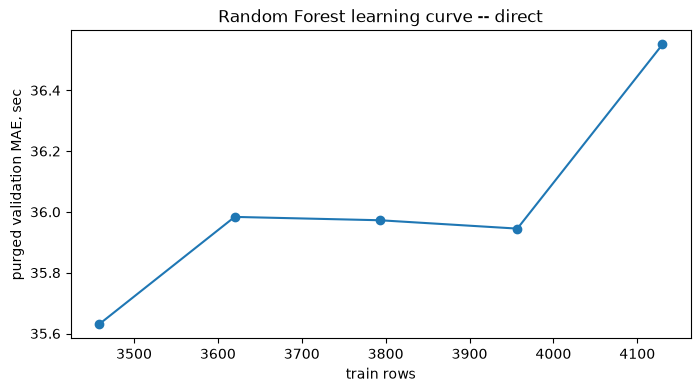

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(rf_learning.train_rows, rf_learning.valid_mae, marker='o')
plt.title(f'Random Forest learning curve -- {rf_best_mode}')
plt.xlabel('train rows')
plt.ylabel('purged validation MAE, sec')
plt.show()

## 8. Official test

In [24]:
def rf_fit_full_predict(train_data, train_x, train_y, train_cur, eval_x, eval_cur, mode, params, n_estimators):
    rf_weights = rf_sample_weight(train_data, params['synthetic_weight'])
    rf_active = rf_weights > 0
    rf_preprocessor = rf_make_preprocessor()
    rf_train_matrix = rf_preprocessor.fit_transform(train_x.loc[rf_active])
    rf_eval_matrix = rf_preprocessor.transform(eval_x)

    rf_fit_target = train_y.loc[rf_active].copy()
    if mode == 'residual':
        rf_fit_target = rf_fit_target - train_cur.loc[rf_active]

    rf_model = rf_make_model(params, n_estimators)
    rf_model.fit(rf_train_matrix, rf_fit_target, sample_weight=rf_weights[rf_active])
    rf_prediction = rf_model.predict(rf_eval_matrix)
    if mode == 'residual':
        rf_prediction += eval_cur.to_numpy()
    rf_prediction = rf_clip_prediction(
        rf_prediction,
        train_y.loc[rf_active],
        params['clip_q']
    )
    return rf_model, rf_preprocessor, rf_prediction

In [25]:
rf_test_model, rf_test_preprocessor, rf_test_prediction = rf_fit_full_predict(
    rf_train,
    rf_x_train,
    rf_y_train,
    rf_cur_train,
    rf_x_test,
    rf_cur_test,
    rf_best_mode,
    rf_best_params,
    RF_FINAL_ESTIMATORS
)

rf_test_metrics = pd.Series({
    'rf_test_mae': mean_absolute_error(rf_y_test, rf_test_prediction),
    'cur_dev_test_mae': mean_absolute_error(rf_y_test, rf_cur_test),
    'improvement_sec': mean_absolute_error(rf_y_test, rf_cur_test)
        - mean_absolute_error(rf_y_test, rf_test_prediction)
})
rf_test_metrics

rf_test_mae         43.055523
cur_dev_test_mae    93.359773
improvement_sec     50.304251
dtype: float64

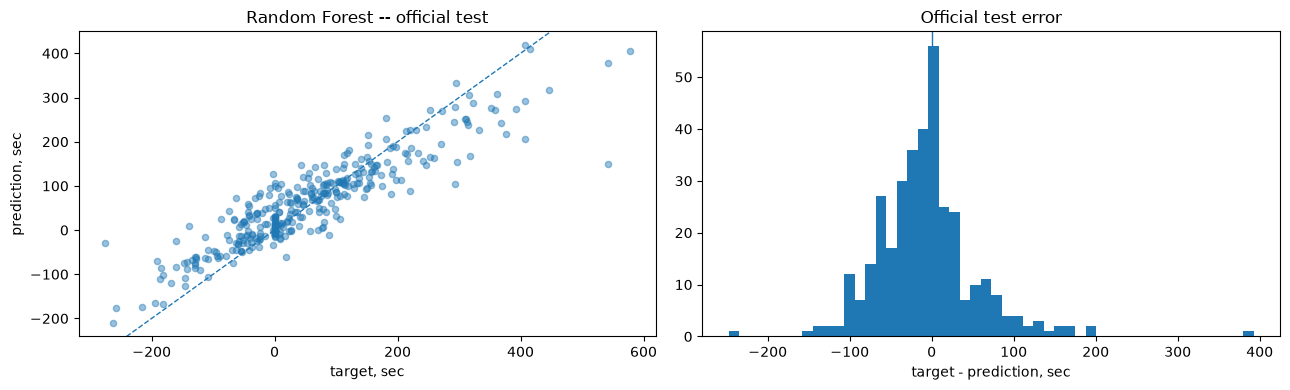

In [26]:
rf_test_error = rf_y_test.to_numpy() - rf_test_prediction
rf_fig, rf_axes = plt.subplots(1, 2, figsize=(13, 4))
rf_axes[0].scatter(rf_y_test, rf_test_prediction, s=20, alpha=.45)
rf_axes[0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
rf_axes[0].set_title('Random Forest -- official test')
rf_axes[0].set_xlabel('target, sec')
rf_axes[0].set_ylabel('prediction, sec')
rf_axes[1].hist(rf_test_error, bins=50)
rf_axes[1].axvline(0, linewidth=1)
rf_axes[1].set_title('Official test error')
rf_axes[1].set_xlabel('target - prediction, sec')
plt.tight_layout()

## 9. Final retune на train + test

In [27]:
rf_all = pd.concat([rf_train, rf_test], ignore_index=True)
rf_x_all = rf_prepare_frame(rf_all)
rf_y_all = rf_all.target_delay_s.astype(float)
rf_cur_all = rf_all.cur_dev_s.astype(float)
rf_final_folds = rf_build_purged_folds(rf_all, RF_OOF_FOLDS, RF_PURGE_MINUTES)

rf_final_study = optuna.create_study(
    study_name=f'rf_{rf_best_mode}_final',
    storage=rf_storage,
    load_if_exists=True,
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RF_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
if len(rf_final_study.trials) == 0:
    rf_final_enqueue_params = {
        rf_key: rf_value
        for rf_key, rf_value in rf_best_study.best_params.items()
        if rf_key != 'criterion'
    }
    rf_final_study.enqueue_trial(rf_final_enqueue_params)

rf_final_finished = sum(
    rf_trial.state in {
        optuna.trial.TrialState.COMPLETE,
        optuna.trial.TrialState.PRUNED
    }
    for rf_trial in rf_final_study.trials
)
rf_final_remaining = max(0, RF_FINAL_TRIALS - rf_final_finished)
if rf_final_remaining:
    rf_final_study.optimize(
        lambda rf_trial: rf_objective(
            rf_trial,
            rf_best_mode,
            rf_all,
            rf_x_all,
            rf_y_all,
            rf_cur_all,
            rf_final_folds
        ),
        n_trials=rf_final_remaining,
        n_jobs=1,
        show_progress_bar=False
    )

rf_final_params = rf_suggest_params(rf_final_study.best_trial)
pd.Series(rf_final_params, name='value').to_frame()

[I 2026-09-27 01:54:01,478] A new study created in RDB with name: rf_direct_final
[I 2026-09-27 01:55:19,486] Trial 0 finished with value: 41.32778183769993 and parameters: {'unlimited_depth': True, 'bootstrap': False, 'min_samples_leaf': 1, 'min_samples_split': 3, 'max_features': 0.2220336148131886, 'min_impurity_decrease': 2.3215458032602815e-09, 'synthetic_weight': 0.75, 'clip_q': 0.005}. Best is trial 0 with value: 41.32778183769993.
[I 2026-09-27 01:56:11,545] Trial 1 finished with value: 55.21197632126647 and parameters: {'unlimited_depth': False, 'bootstrap': False, 'max_depth': 21, 'min_samples_leaf': 11, 'min_samples_split': 2, 'max_features': 0.20702716521874953, 'min_impurity_decrease': 1.5682906073517883e-08, 'synthetic_weight': 0.1, 'clip_q': 0.001}. Best is trial 0 with value: 41.32778183769993.
[I 2026-09-27 01:56:31,295] Trial 2 finished with value: 71.45334389819432 and parameters: {'unlimited_depth': True, 'bootstrap': True, 'min_samples_leaf': 1, 'min_samples_split':

,value
max_depth,None
min_samples_leaf,1
min_samples_split,3
max_features,0.222034
bootstrap,False
criterion,squared_error
min_impurity_decrease,0.0
synthetic_weight,0.75
clip_q,0.005
max_samples,None


## 10. Final fit и submission

In [28]:
rf_final_model, rf_final_preprocessor, rf_validate_prediction = rf_fit_full_predict(
    rf_all,
    rf_x_all,
    rf_y_all,
    rf_cur_all,
    rf_x_validate,
    rf_cur_validate,
    rf_best_mode,
    rf_final_params,
    RF_FINAL_ESTIMATORS
)

rf_submission_dir = Path('../submissions/random_forest')
rf_submission_dir.mkdir(parents=True, exist_ok=True)
rf_submission_template = pd.read_csv('../dataset/sample_submission.csv', sep=';')
rf_pred_map = pd.Series(rf_validate_prediction, index=rf_validate.sample_id)
rf_submission = rf_submission_template.copy()
rf_submission['prediction'] = rf_submission.sample_id.map(rf_pred_map)
assert rf_submission.prediction.notna().all()
assert rf_submission.sample_id.is_unique

rf_submission_path = rf_submission_dir / f'random_forest_optuna_{rf_best_mode}.csv'
rf_submission.to_csv(rf_submission_path, sep=';', index=False)
rf_submission_path

PosixPath('../submissions/random_forest/random_forest_optuna_direct.csv')

In [29]:
rf_oof.to_csv(rf_artifact_dir / 'oof_train.csv', index=False)
rf_stress_oof.to_csv(rf_artifact_dir / 'oof_group_stress.csv', index=False)
rf_importance_stability.to_csv(rf_artifact_dir / 'feature_importance_stability.csv')
rf_study_table.to_csv(rf_artifact_dir / 'study_summary.csv', index=False)
rf_test_metrics.rename('value').to_csv(rf_artifact_dir / 'test_metrics.csv')

pd.Series({
    'selected_mode': rf_best_mode,
    'train_cv_mae': rf_oof.abs_error.mean(),
    'group_stress_mae': rf_stress_oof.abs_error.mean(),
    'official_test_mae': mean_absolute_error(rf_y_test, rf_test_prediction),
    'submission': str(rf_submission_path)
})

selected_mode                                                   direct
train_cv_mae                                                 41.345142
group_stress_mae                                             41.566829
official_test_mae                                            43.055523
submission           ../submissions/random_forest/random_forest_opt...
dtype: object

In [30]:
import pickle

rf_checkpoint_dir = rf_artifact_dir / 'checkpoints'
rf_checkpoint_dir.mkdir(parents=True, exist_ok=True)

rf_checkpoint = {
    'model': rf_final_model,
    'preprocessor': rf_final_preprocessor,
    'mode': rf_best_mode,
    'params': rf_final_params,
    'feature_cols': rf_feature_cols,
    'numeric_features': rf_numeric_features,
    'categorical_features': rf_categorical_features,
    'n_estimators': RF_FINAL_ESTIMATORS,
    'cv_mae': rf_final_study.best_value,
}

rf_checkpoint_path = rf_checkpoint_dir / 'random_forest_final.pkl'

with open(rf_checkpoint_path, 'wb') as rf_file:
    pickle.dump(rf_checkpoint, rf_file)

rf_checkpoint_path

PosixPath('../artifacts/models/random_forest/checkpoints/random_forest_final.pkl')